In [1]:
import pandas as pd
from cd_base import ConexionBD
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.gridspec as gridspec
from concurrent.futures import ThreadPoolExecutor


#Gráficas en Century Gothic

plt.rcParams['font.family'] = 'Century Gothic'

c:\Users\claud\miniconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\claud\miniconda3\Lib\site-packages\paramiko\transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


In [2]:
##Crear carpetas de almacenamiento
ruta_graficas = 'graficos/avance_satisf'
os.makedirs(ruta_graficas, exist_ok=True)


In [3]:
##Conexión a base de datos
bd= ConexionBD("I:\\Mi unidad\\credenciales\\bd_produccion.txt")
engine = bd.conectar("escolar")

✅ Conectado a base: escolar


In [4]:
##Traer los niveles de estudio
niveles=pd.read_sql_query("SELECT * from tb_plan_estudio_nivel_estudio",engine)
#Filtrar solo prepa, licenciatura, ingeniería y maestría
niveles = niveles[niveles["nombre"].isin(["PREPARATORIA", "LICENCIATURA", "INGENIERIA", "MAESTRIA"])]
niveles

,id,nombre,activo,id_usuario_reg,fecha_reg
2,3,PREPARATORIA,1,477,2024-02-06 17:32:56
3,4,LICENCIATURA,1,477,2024-02-06 17:32:57
4,5,MAESTRIA,1,477,2024-02-06 17:32:57
8,9,INGENIERIA,1,477,2024-02-06 17:33:15


In [5]:
### Traer planes de estudio
planes=pd.read_sql("SELECT * from tb_plan_estudio",engine)
planes = planes[["id", "nombre_publico"]]
planes

,id,nombre_publico
0,1,None
1,2,Bachillerato (Prepa Coppel)
2,3,None
3,4,None
4,5,Bachillerato (Nueva Prepa Coppel)
...,...,...
84,133,BACHILLERATO FALCO ELECTRONICS
85,134,LICENCIATURA STRYKER
86,135,Ingenieria en Desarrollo de Software
87,136,Prepa Bayer TEMPORALES


In [6]:
## Cerrar el túnel
bd.cerrar()

🔒 Engine cerrado
🔒 Túnel SSH cerrado


In [7]:
##Crear conexión a ciencia_datos para corer los SPs
engine=bd.conectar("ciencia_datos")

✅ Conectado a base: ciencia_datos


#### Avance académico

In [27]:
query="""
call sp_avance_academico_materias(2023)
"""


avances= pd.read_sql(query,engine)

avances

,id_alumno,id_moodle,id_migracion,id_plan_estudio,plan,id_corporacion,corporacion,anio_inscripcion,fecha_inscripcion,periodo_inscripcion,...,primer_carga,materias_totales,materias_totales_curriculares,id_materia,nombre_materia,periodo,calificacion,fecha_carga,fecha_fin,tipo_calificacion
0,176161,45227,0,13,PREPA SUMATE,8,MABE,2025,2025-01-10 12:12:44,2025-01-10,...,NaT,30,30,NaN,None,NaN,NaN,NaT,NaT,None
1,117070,10725,1934,14,LDG LEY,4,CASA LEY,2023,2023-01-26 10:49:00,2023-02-01,...,2023-02-01 13:09:07,50,48,307.0,Introducción a los Modelos Ágiles de Administr...,1.0,NaN,2023-02-01 13:09:07,NaT,None
2,117070,10725,1934,14,LDG LEY,4,CASA LEY,2023,2023-01-26 10:49:00,2023-02-01,...,2023-02-01 13:09:07,50,48,309.0,Psicología Organizacional,1.0,NaN,2023-03-21 13:34:40,NaT,None
3,117070,10725,1934,14,LDG LEY,4,CASA LEY,2023,2023-01-26 10:49:00,2023-02-01,...,2023-02-01 13:09:07,50,48,310.0,Habilidades de Razonamiento Matemático. (Razon...,1.0,NaN,2023-03-21 13:34:36,NaT,None
4,117070,10725,1934,14,LDG LEY,4,CASA LEY,2023,2023-01-26 10:49:00,2023-02-01,...,2023-02-01 13:09:07,50,48,311.0,Teoría del Conocimiento,1.0,NaN,2023-02-01 13:09:10,NaT,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162071,126886,58648,0,137,INGENIERÍA INDUSTRIAL COPPEL,2,COPPEL,2026,2026-04-05 17:06:42,2026-04-01,...,NaT,1,1,NaN,None,NaN,NaN,NaT,NaT,None
162072,126935,58647,0,137,INGENIERÍA INDUSTRIAL COPPEL,2,COPPEL,2026,2026-04-05 17:04:02,2026-04-01,...,NaT,1,1,NaN,None,NaN,NaN,NaT,NaT,None
162073,158637,58649,0,137,INGENIERÍA INDUSTRIAL COPPEL,2,COPPEL,2026,2026-04-05 17:24:49,2026-04-01,...,NaT,1,1,NaN,None,NaN,NaN,NaT,NaT,None
162074,202324,58645,0,137,INGENIERÍA INDUSTRIAL COPPEL,2,COPPEL,2026,2026-04-05 16:53:51,2026-04-01,...,NaT,1,1,NaN,None,NaN,NaN,NaT,NaT,None


In [105]:
##Revisar año de inscripción
avances["anio_inscripcion"].unique()

array([2025, 2023, 2024, 2026])

In [85]:
# Filtrar solo filas con fecha_carga y fecha_fin no nulas
avances_validos = avances.dropna(subset=['fecha_carga', 'fecha_fin'])

# Calcular diferencia en días
avances_validos['dias_para_terminar'] = (avances_validos['fecha_fin'] - avances_validos['fecha_carga']).dt.days
avances_validos = avances_validos[avances_validos["dias_para_terminar"] >= 0]

# Promedio de tiempo por alumno (por si un alumno tiene varias materias)
promedio_por_alumno = avances_validos.groupby('id_alumno')['dias_para_terminar'].mean()

# Promedio general
promedio_general = avances_validos['dias_para_terminar'].mean()

print(f"Promedio general de días para terminar una materia: {promedio_general:.1f} días")

Promedio general de días para terminar una materia: 25.7 días


In [90]:
promedio_por_alumno = avances_validos.groupby("id_alumno")["dias_para_terminar"].mean()

debajo = (promedio_por_alumno < promedio_general).sum()
total = len(promedio_por_alumno)
print(f"{debajo/total*100:.1f}% de alumnos acaba las materias por debajo del promedio de días")

52.9% de alumnos acaba las materias por debajo del promedio de días


In [106]:
#Máximos y mínimos de días para concluir materias
print(min(avances_validos["dias_para_terminar"]))
print(max(avances_validos["dias_para_terminar"]))

0
1062


In [87]:
# Promedio por id_plan_estudio
nombres_plan = planes[['id', 'nombre_publico']].drop_duplicates()
promedio_por_plan = avances_validos.groupby('id_plan_estudio')['dias_para_terminar'].mean().reset_index()
promedio_por_plan.columns = ['id_plan_estudio', 'promedio_dias']
promedio_por_plan = promedio_por_plan.merge(
    planes[['id', 'nombre_publico']], 
    left_on='id_plan_estudio', 
    right_on='id', 
    how='left'
).drop(columns='id').sort_values('promedio_dias', ascending=False)

promedio_por_plan

,id_plan_estudio,promedio_dias,nombre_publico
15,71,87.200000,PREPARATORIA PIZZA HUT
1,16,62.455446,None
13,69,58.733333,Licenciatura en Gerenciamiento Index
20,89,47.016086,MAESTRIA EN DIRECCIÓN DE NEGOCIOS
2,17,46.204878,Bachillerato General con Formación para el Tra...
7,50,43.998518,Maestría en Dirección de Negocios
14,70,42.531250,Ingeniería en Desarrollo de Software
0,14,37.716036,"Licenciatura en Gerenciamiento, Ventas y Servicio"
3,18,35.699251,Ingeniería en Desarrollo de Software
12,68,34.838269,BACHILLERATO INDEX


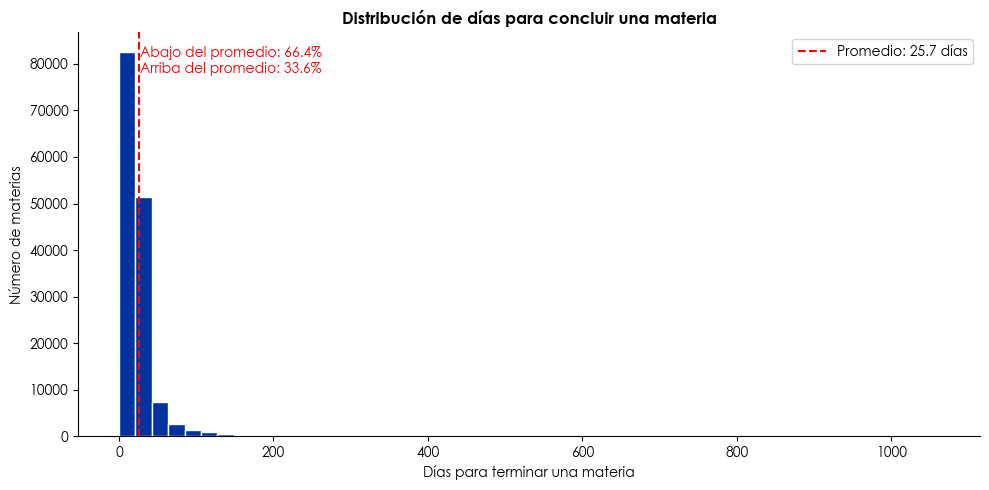

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(avances_validos["dias_para_terminar"], bins=50, color="#0033A0", edgecolor="white")
ax.axvline(promedio_general, color="red", linestyle="--", linewidth=1.5, label=f"Promedio: {promedio_general:.1f} días")

debajo = (avances_validos["dias_para_terminar"] < promedio_general).sum()
arriba = (avances_validos["dias_para_terminar"] >= promedio_general).sum()
total = len(avances_validos)

ax.text(promedio_general + 2, ax.get_ylim()[1] * 0.9, 
        f"Abajo del promedio: {debajo/total*100:.1f}%\nArriba del promedio: {arriba/total*100:.1f}%",
        color="red", fontsize=10)

ax.set_xlabel("Días para terminar una materia")
ax.set_ylabel("Número de materias")
ax.set_title("Distribución de días para concluir una materia",fontweight="bold")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(f'{ruta_graficas}/avance_dias_distrib.png', dpi=150, bbox_inches='tight')

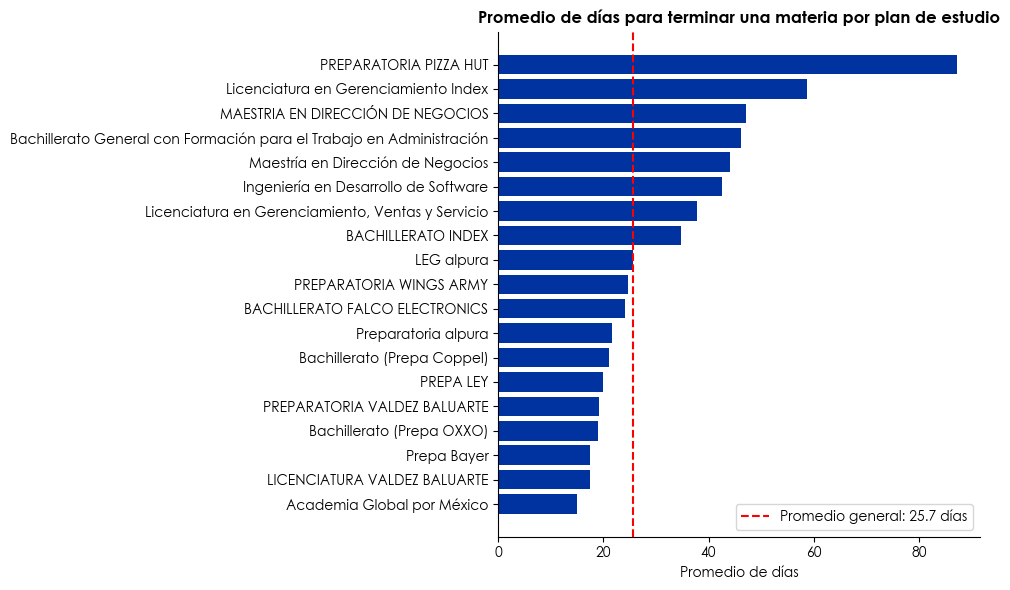

In [95]:
data = promedio_por_plan.dropna(subset=['nombre_publico'])

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(data['nombre_publico'], data['promedio_dias'], color="#0033A0")
ax.axvline(promedio_general, color="red", linestyle="--", linewidth=1.5, label=f"Promedio general: {promedio_general:.1f} días")

ax.set_xlabel('Promedio de días')
ax.set_title('Promedio de días para terminar una materia por plan de estudio', fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.savefig(f'{ruta_graficas}/avance_dias_termino.png', dpi=150, bbox_inches='tight')
plt.show()

In [107]:
# Quitar registros sin fecha_carga
con_carga = avances[avances["fecha_carga"].notna()].copy()

# Extraer año de fecha_carga
con_carga["anio_carga"] = con_carga["fecha_carga"].dt.year


# Activas: tienen fecha_carga pero no fecha_fin
resumen = con_carga.groupby("anio_carga").agg(
    total_materias=("id_materia", "count"),
    activas=("fecha_fin", lambda x: x.isna().sum()),
    concluidas=("fecha_fin", lambda x: x.notna().sum())
).assign(pct_activas=lambda df: (df["activas"] / df["total_materias"] * 100).round(1))

resumen


,total_materias,activas,concluidas,pct_activas
anio_carga,,,,
2022,13,0,13,0.0
2023,25882,2257,23625,8.7
2024,58793,3224,55569,5.5
2025,59471,2969,56502,5.0
2026,17058,3990,13068,23.4


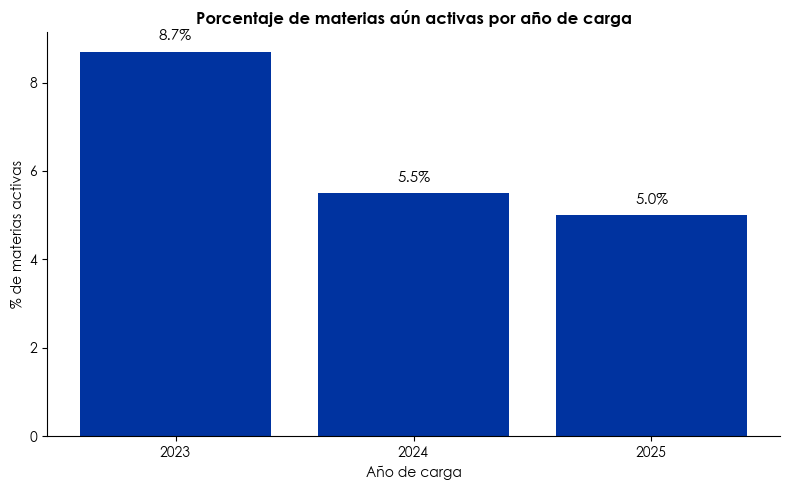

In [108]:
resumen_filtrado = resumen[resumen.index.isin([2023, 2024, 2025])]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(resumen_filtrado.index.astype(str), resumen_filtrado["pct_activas"], color="#0033A0")

for i, (x, y) in enumerate(zip(resumen_filtrado.index.astype(str), resumen_filtrado["pct_activas"])):
    ax.text(i, y + 0.2, f"{y}%", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Año de carga")
ax.set_ylabel("% de materias activas")
ax.set_title("Porcentaje de materias aún activas por año de carga", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig(f'{ruta_graficas}/avance_materias_activas.png', dpi=150, bbox_inches='tight')
plt.tight_layout()


In [ ]:
# Porcentaje de avance por año de inscripción
avance_alumno = con_carga.groupby(["id_alumno", "id_migracion", "anio_inscripcion"]).agg(
    materias_cursadas=("id_materia", "count"),
    materias_concluidas=("fecha_fin", lambda x: x.notna().sum()),
    materias_totales_curriculares=("materias_totales_curriculares", "first")
).reset_index()

avance_alumno["pct_avance"] = (
    avance_alumno["materias_concluidas"] / avance_alumno["materias_totales_curriculares"] * 100
).round(1)

# Resumen por año de inscripción
avance_alumno.groupby("anio_inscripcion").agg(
    alumnos=("id_alumno", "nunique"),
    promedio_pct_avance=("pct_avance", "mean"),
    mediana_pct_avance=("pct_avance","median")
).round(1)


,alumnos,promedio_pct_avance,mediana_pct_avance
anio_inscripcion,,,
2023,4190,41.0,21.2
2024,3461,38.6,24.2
2025,2582,24.0,18.2
2026,685,5.9,6.1


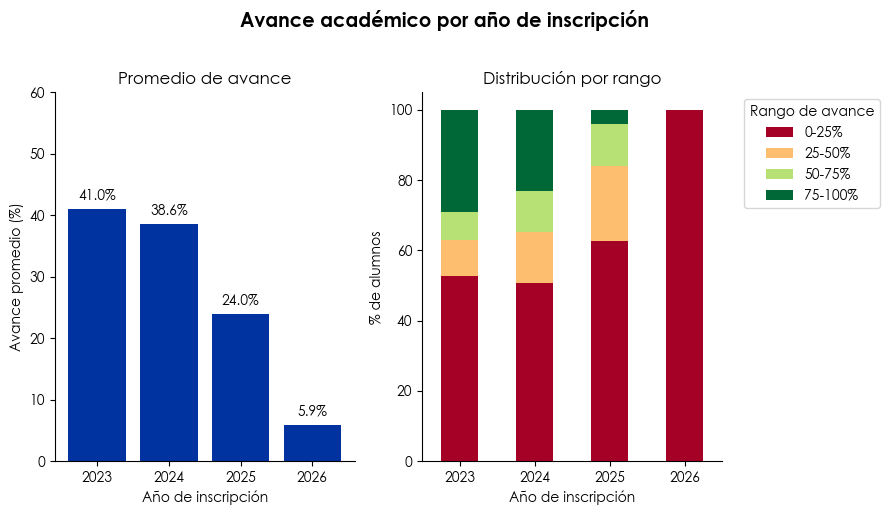

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Avance académico por año de inscripción", fontsize=14, y=1.02, fontweight="bold")

plt.subplots_adjust(wspace=0.3)

# Barras - promedio
bars = ax1.bar(resumen["anio_inscripcion"].astype(str), resumen["promedio_pct_avance"], color="#0033A0")
ax1.set_title("Promedio de avance")
ax1.set_xlabel("Año de inscripción")
ax1.set_ylabel("Avance promedio (%)")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, 60)
for bar, val in zip(bars, resumen["promedio_pct_avance"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val}%", ha="center", va="bottom")

# Barras apiladas - rangos
bins = [0, 25, 50, 75, 100]
labels = ["0-25%", "25-50%", "50-75%", "75-100%"]
avance_alumno["rango"] = pd.cut(avance_alumno["pct_avance"], bins=bins, labels=labels, include_lowest=True)


tabla = avance_alumno.groupby(["anio_inscripcion", "rango"]).size().unstack().fillna(0)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

tabla_pct.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="RdYlGn", ax=ax2)
ax2.set_xlabel("Año de inscripción")
ax2.set_title("Distribución por rango")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.set_ylabel("% de alumnos")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title="Rango de avance", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig(f'{ruta_graficas}/avance_por_anio_inscrip.png', dpi=150, bbox_inches='tight')


#### Satisfacción

In [16]:
#Traer las calificaciones por nivel 
query = """
call sp_promedio_encuesta_nivel({});
"""
dfs = []
for id_nivel in niveles["id"]:
    df = pd.read_sql(query.format(id_nivel), engine)
    dfs.append(df)

calif_satis_gral = pd.concat(dfs, ignore_index=True)
calif_satis_gral

,id_nivel_estudio,nivel_estudio,id_corporacion,corporacion,promedio
0,3,PREPARATORIA,14,ALPURA,9.1
1,3,PREPARATORIA,12,INDEX,8.6
2,3,PREPARATORIA,13,ACADEMIA GLOBAL POR MÉXICO,8.5
3,3,PREPARATORIA,15,BAYER,9.0
4,3,PREPARATORIA,2,COPPEL,9.4
5,3,PREPARATORIA,4,CASA LEY,9.2
6,3,PREPARATORIA,1,AG COLLEGE,9.4
7,4,LICENCIATURA,14,ALPURA,9.5
8,4,LICENCIATURA,1,AG COLLEGE,9.6
9,4,LICENCIATURA,2,COPPEL,9.6


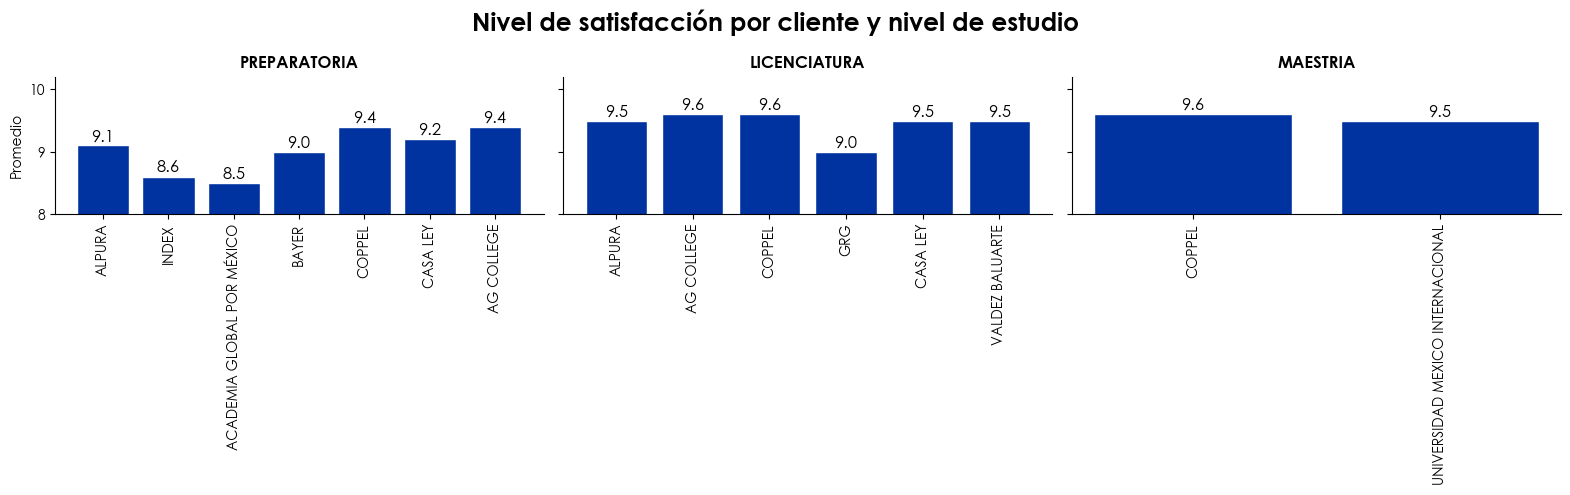

In [17]:
##Calificaciones generales
niveles = calif_satis_gral['nivel_estudio'].unique()
fig, axes = plt.subplots(1, len(niveles), figsize=(16, 5), sharey=True)

for ax, nivel in zip(axes, niveles):
    df_nivel = calif_satis_gral[calif_satis_gral['nivel_estudio'] == nivel]
    bars = ax.bar(df_nivel['corporacion'], df_nivel['promedio'], color='#0033A0', edgecolor='white')
    
    for bar, val in zip(bars, df_nivel['promedio']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.1f}', ha='center', va='bottom', fontsize=12)
    
    ax.set_title(nivel, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(8, 10.2)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Promedio')
fig.suptitle('Nivel de satisfacción por cliente y nivel de estudio', 
             fontsize=18, fontweight='bold')
plt.tight_layout()

plt.savefig(f'{ruta_graficas}/satisfaccion_por_nivel.png', dpi=150, bbox_inches='tight')

In [18]:
## Satisfacción por materia


query = """
call escolar.sp_promedio_encuesta_satisfaccion ({});
"""

materias = []
for id_planes in planes["id"]:
    df = pd.read_sql(query.format(id_planes), engine)
    materias.append(df)

calif_satis_mat = pd.concat(materias, ignore_index=True)
calif_satis_mat

,id,id_materia,id_periodo,id_encuesta,nombre_materia,promedio
0,1,7850,1,3593,Psicología Organizacional,9.3
1,2,7853,1,3594,Entorno Exponencial y Transformación Empresari...,9.4
2,3,7849,1,3590,Introducción a los Modelos Ágiles de Administr...,9.5
3,4,7852,1,3591,Teoría del Conocimiento,9.4
4,5,7851,1,3592,Habilidades de Razonamiento Matemático. (Razon...,9.5
...,...,...,...,...,...,...
787,15,9102,3,4109,Certificación Ejecutiva en Cultura Emprendedora,4.4
788,16,9080,3,4110,Física I y II,7.9
789,17,9083,3,4106,Inglés III,6.0
790,18,9079,3,4108,Matemáticas III,3.9


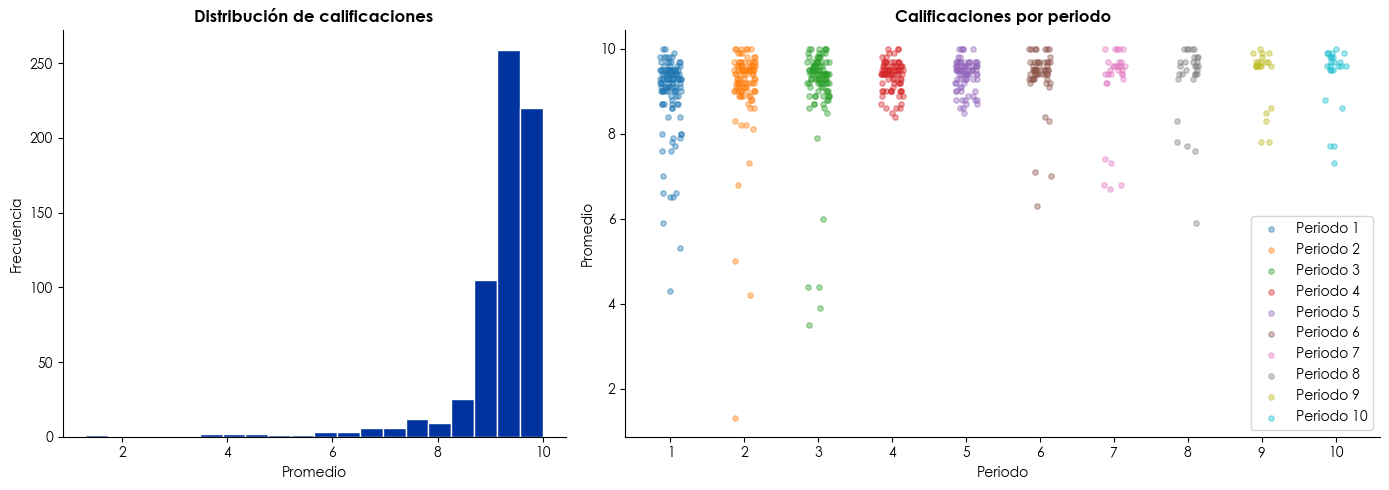

In [19]:
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5])

# Histograma general
ax1 = fig.add_subplot(gs[0])
ax1.hist(calif_satis_mat["promedio"], bins=20, color="#0033A0", edgecolor="white")
ax1.set_xlabel("Promedio")
ax1.set_ylabel("Frecuencia")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title("Distribución de calificaciones", fontweight="bold")

# Scatter por periodo con jitter
ax2 = fig.add_subplot(gs[1])
for periodo, grupo in calif_satis_mat.groupby("id_periodo"):
    jitter = np.random.uniform(-0.15, 0.15, size=len(grupo))
    ax2.scatter(periodo + jitter, grupo["promedio"], alpha=0.4, s=15, label=f"Periodo {periodo}")

ax2.set_xlabel("Periodo")
ax2.set_ylabel("Promedio")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title("Calificaciones por periodo",fontweight="bold")
ax2.legend()
ax2.set_xticks(calif_satis_mat["id_periodo"].unique().astype(int))  # fix

plt.tight_layout()
plt.savefig(f'{ruta_graficas}/satisfaccion_por_periodo.png', dpi=150, bbox_inches='tight')


In [129]:
materias_malas=calif_satis_mat[calif_satis_mat["promedio"] < 9].groupby(["id_materia", "nombre_materia"])["promedio"].agg(["mean", "count"]).sort_values("mean", ascending=True)
materias_malas

,,mean,count
id_materia,nombre_materia,,
9074,Matemáticas II,1.3,1
9082,Literatura I y II,3.5,1
9079,Matemáticas III,3.9,1
9077,Taller de Lectura y Redacción II,4.2,1
9097,Metodología de la Investigación,4.3,1
...,...,...,...
8013,Habilidades Numéricas Financieras. (Matemáticas Financieras),8.9,1
5964,Matemáticas I,8.9,1
8165,Análisis Financiero para la Toma de Decisiones. (Información Financiera para la Toma de Decisiones),8.9,1


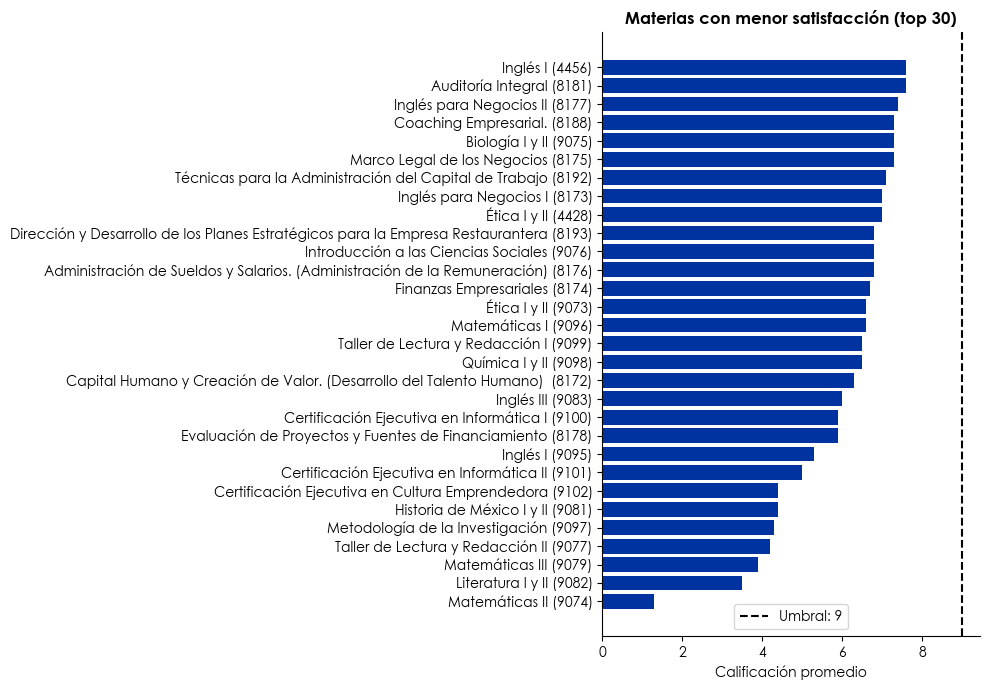

In [143]:
materias_malas_t = materias_malas.sort_values("mean", ascending=True).head(30).reset_index()
materias_malas_t["etiqueta"] = materias_malas_t["nombre_materia"] + " (" + materias_malas_t["id_materia"].astype(str) + ")"


fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(materias_malas_t["etiqueta"], materias_malas_t["mean"], color="#0033A0")

ax.axvline(9, color="black", linestyle="--", linewidth=1.5, label="Umbral: 9")

ax.set_xlabel("Calificación promedio")
ax.set_title("Materias con menor satisfacción (top 30)", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.savefig(f'{ruta_graficas}/satisfaccion_materias_malas.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
